# 🏦 Credit Default Prediction — End-to-End Machine Learning Pipeline

> **Objective:** Build a production-ready binary classifier that predicts whether a loan applicant will default,  
> using customer demographics, loan attributes, and bureau data.  
> The final model is serialised to disk for deployment via a REST API.

---

## 📋 Table of Contents

| # | Section |
|---|---------|
| 1 | [Library Imports](#1-library-imports) |
| 2 | [Data Loading & Initial Inspection](#2-data-loading--initial-inspection) |
| 3 | [Train-Test Split (Pre-EDA)](#3-train-test-split-pre-eda) |
| 4 | [Missing Value Treatment](#4-missing-value-treatment) |
| 5 | [Exploratory Data Analysis (EDA)](#5-exploratory-data-analysis) |
| 6 | [Outlier Detection & Data Quality Checks](#6-outlier-detection--data-quality-checks) |
| 7 | [Feature Engineering](#7-feature-engineering) |
| 8 | [Feature Selection — VIF & Correlation](#8-feature-selection--vif--correlation) |
| 9 | [Feature Selection — WoE & Information Value](#9-feature-selection--woe--information-value) |
| 10 | [Encoding & Final Feature Matrix](#10-encoding--final-feature-matrix) |
| 11 | [Baseline Modelling](#11-baseline-modelling) |
| 12 | [Hyperparameter Tuning — RandomizedSearchCV](#12-hyperparameter-tuning--randomizedsearchcv) |
| 13 | [Class Imbalance Handling — SMOTETomek](#13-class-imbalance-handling--smotetomek) |
| 14 | [Bayesian Hyperparameter Optimisation — Optuna](#14-bayesian-hyperparameter-optimisation--optuna) |
| 15 | [Model Evaluation — ROC-AUC & Gini](#15-model-evaluation--roc-auc--gini) |
| 16 | [Model Evaluation — Rank Order & KS Statistic](#16-model-evaluation--rank-order--ks-statistic) |
| 17 | [Model Explainability — SHAP](#17-model-explainability--shap) |
| 18 | [Model Export for Production](#18-model-export-for-production) |

---

## 🗂️ Dataset Overview

Three relational CSV files joined on `cust_id`:

| File | Contents |
|------|----------|
| `customers.csv` | Demographics: age, gender, income, employment status, residence info |
| `loans.csv` | Loan details: amount, tenure, processing fee, GST, disbursement date |
| `bureau_data.csv` | Credit bureau signals: DPD, delinquency months, open/closed accounts, utilisation ratio |

**Target variable:** `default` — binary (1 = defaulted, 0 = did not default)

---

## 🔑 Key Results Summary

| Metric | Value |
|--------|-------|
| Best Model | Logistic Regression (Optuna-tuned, trained on SMOTETomek-resampled data) |
| Macro F1 (CV) | **0.9776** |
| AUC-ROC | Computed and plotted (Section 15) |
| Gini Coefficient | `2 × AUC − 1` (Section 15) |
| Max KS Statistic | Computed across decile table (Section 16) |
| Output Artifact | `./artifacts/credit_risk.joblib` |


---
## 1. Library Imports

All dependencies are imported up-front for clarity and to fail fast if any package is missing.

| Library | Role in this project |
|---------|----------------------|
| `numpy` | Numerical operations (log transforms, array maths) |
| `pandas` | Tabular data manipulation, merging, groupby aggregations |
| `matplotlib` / `seaborn` | Visualisations — boxplots, histograms, KDE plots, heatmaps |
| `sklearn.model_selection` | `train_test_split`, `cross_val_score`, `RandomizedSearchCV` |
| `sklearn.preprocessing` | `MinMaxScaler` — normalises numeric features to [0, 1] before VIF calculation |
| `statsmodels` | `variance_inflation_factor` — detects multicollinearity among features |
| `sklearn.linear_model` | `LogisticRegression` — final chosen model |
| `sklearn.tree` | `DecisionTreeClassifier` — baseline candidate |
| `sklearn.ensemble` | `RandomForestClassifier` — baseline candidate |
| `xgboost` | `XGBClassifier` — gradient boosting baseline and Optuna candidate |
| `sklearn.metrics` | `classification_report`, `roc_curve`, `auc`, `f1_score`, `make_scorer` |
| `imblearn` | `SMOTETomek` — hybrid oversampling + undersampling to handle class imbalance |
| `optuna` | Bayesian hyperparameter optimisation via Tree-structured Parzen Estimator |
| `shap` | Model-agnostic feature importance and explainability (SHAP values) |
| `joblib` | Serialises the trained model pipeline to disk for API deployment |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, recall_score, make_scorer, f1_score, roc_curve, auc
from imblearn.combine import SMOTETomek
import optuna
import shap
from joblib import dump

C:\Users\soham\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 2. Data Loading & Initial Inspection

The dataset is split across three CSV files representing different domains of information 
about the same customer. Each file shares `cust_id` as the primary key, allowing a clean 
inner join to produce a single flat table.

> **Design note:** Loading separate files (rather than a single denormalised table) mirrors 
> real-world credit risk systems where customer, loan, and bureau data come from different 
> upstream systems.


In [2]:
# Load each domain-specific table from the data directory
df_customers = pd.read_csv("./data/customers.csv")
df_loans     = pd.read_csv("./data/loans.csv")
df_bereau    = pd.read_csv("./data/bureau_data.csv")

### 2.1 Inspect individual table shapes

Printing shapes before joining confirms whether the tables are truly one-to-one on `cust_id`. 
If row counts differ significantly, it would signal one-to-many relationships requiring aggregation first.


In [3]:
# Verify row counts — all three should have the same number of rows
# if the relationship is strictly one-to-one on cust_id
print("Customers table shape :", df_customers.shape)
print("Loans table shape      :", df_loans.shape)
print("Bureau table shape     :", df_bereau.shape)

Customers table shape : (50000, 12)
Loans table shape      : (50000, 15)
Bureau table shape     : (50000, 8)


### 2.2 Preview each table


In [4]:
df_customers.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001


In [5]:
df_loans.head()

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [6]:
df_bereau.head()

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58
3,C00004,3,0,115,15,87,5,26
4,C00005,4,2,120,0,0,5,10


### 2.3 Merge into a single analytical table

All three tables are confirmed to have a one-to-one relationship on `cust_id`, 
so they are merged sequentially using inner joins. The result is a single flat 
DataFrame containing all features required for modelling.


In [7]:
# Sequential inner merge: customers ← loans ← bureau
# Inner join ensures only customers present in all three tables are retained
df = pd.merge(df_customers, df_loans,  on='cust_id')
df = pd.merge(df,           df_bereau, on='cust_id')

In [8]:
# Inspect merged DataFrame — confirms all columns are present
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


In [9]:
# Check dtypes and non-null counts to identify mixed-type or missing columns early
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

### 2.4 Class distribution — Target variable

Understanding the ratio of defaulters to non-defaulters upfront is critical: a severe 
imbalance means raw accuracy is a misleading metric and that standard training will bias 
the model toward the majority class. This check motivates the SMOTETomek step applied later.


In [10]:
# Absolute counts of each class (1 = default, 0 = no default)
# A large imbalance here signals the need for resampling techniques later
df.default.value_counts()

default
False    45703
True      4297
Name: count, dtype: int64

---
## 3. Train-Test Split (Pre-EDA)

**Why split before EDA?** Performing exploratory analysis on the full dataset before 
splitting introduces *data leakage*: imputation statistics (e.g. mode, mean) or outlier 
thresholds derived from the test set influence the training process. To prevent this:

1. The split is performed first, on the raw merged data.
2. All EDA, imputation, scaling, and encoding decisions are derived **exclusively from `df_train`**.
3. The same transformations are then applied to `df_test` without re-fitting.

**Stratification:** `stratify=y` ensures both splits preserve the original class ratio 
(important when the minority class is small — without stratification, the test set 
could end up with no defaulters by chance).

**Split ratio:** 70% train / 30% test — a standard choice that provides sufficient 
data for cross-validated training while leaving a meaningful hold-out for final evaluation.


In [11]:
X = df.drop('default', axis=1)
y = df['default']

# Stratify ensures both splits contain the same class ratio as the full dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42  # Fixed seed for reproducibility
)

# Reconstruct labelled DataFrames for EDA purposes (needed for grouped plots)
df_train = pd.concat([X_train, y_train], axis=1)
df_test  = pd.concat([X_test,  y_test],  axis=1)

---
## 4. Missing Value Treatment

Missing data is assessed only on the training set. The imputed value (mode of `residence_type`) 
is then applied identically to the test set — this is the correct approach to avoid leakage.

**Strategy chosen — Mode imputation:**
- `residence_type` is a low-cardinality categorical column with a dominant majority class.
- Deleting rows with missing values would reduce the training set unnecessarily.
- Mode imputation is appropriate when one category is overwhelmingly frequent, as confirmed 
  by inspecting the value counts before imputing.
- Mean/median imputation is not applicable to categorical features.


In [12]:
# Identify columns with missing values and their counts (training set only)
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 44
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [13]:
# Inspect the unique categories in residence_type before deciding imputation strategy
df_train.residence_type.unique()

array(['Owned', 'Rented', 'Mortgage', nan], dtype=object)

In [14]:
# Compute the mode — the most frequently occurring residence category
mode_residence = df_train.residence_type.mode()[0]
mode_residence

'Owned'

In [15]:
# Confirm mode is the dominant category (validates the imputation choice)
df_train.residence_type.value_counts()

residence_type
Owned       19709
Mortgage     8270
Rented       6977
Name: count, dtype: int64

In [16]:
# Apply mode imputation to BOTH train and test sets
# IMPORTANT: the mode is derived from df_train only — no leakage from test set
df_train['residence_type'] = df_train['residence_type'].fillna(mode_residence)
df_test['residence_type']  = df_test['residence_type'].fillna(mode_residence)

### 4.1 Duplicate Check

Duplicate rows in a tabular dataset can inflate training metrics and cause the model 
to memorise specific records rather than generalise. If duplicates exist, they should 
be removed before modelling.


In [17]:
# Count fully duplicate rows in the training set
df_train.duplicated().sum()

np.int64(0)

---
## 5. Exploratory Data Analysis

EDA is structured around the two feature types in this dataset.

**Continuous features** are examined for:
- Distribution shape (skewness, bimodality)
- Outlier presence via boxplots
- Distributional differences between defaulters and non-defaulters via KDE plots

**Categorical features** are examined for:
- Cardinality (number of unique categories)
- Data quality issues (typos, inconsistent labels)
- Business rule violations (e.g. GST or processing fee exceeding legal limits)

### 5.1 Feature type taxonomy


In [18]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [19]:
# Manually classify features by type — drives different EDA and encoding strategies
columns_categorical = [
    'gender',
    'marital_status',
    'employment_status',
    'residence_type',
    'city',
    'state',
    'zipcode',
    'loan_purpose',
    'loan_type',
    'default'
]

columns_continuous = [
    'age',
    'income',
    'number_of_dependants',
    'years_at_current_address',
    'sanction_amount',
    'loan_amount',
    'processing_fee',
    'gst',
    'net_disbursement',
    'loan_tenure_months',
    'principal_outstanding',
    'bank_balance_at_application',
    'number_of_open_accounts',
    'number_of_closed_accounts',
    'total_loan_months',
    'delinquent_months',
    'total_dpd',
    'enquiry_count',
    'credit_utilization_ratio'
]

### 5.2 Continuous feature distributions — Boxplots

Horizontal boxplots reveal the spread, median, and outlier extent for each continuous feature.
Features with heavy right-skew (e.g. income, total_dpd) suggest the presence of high-value 
outliers that may distort linear models without appropriate treatment.


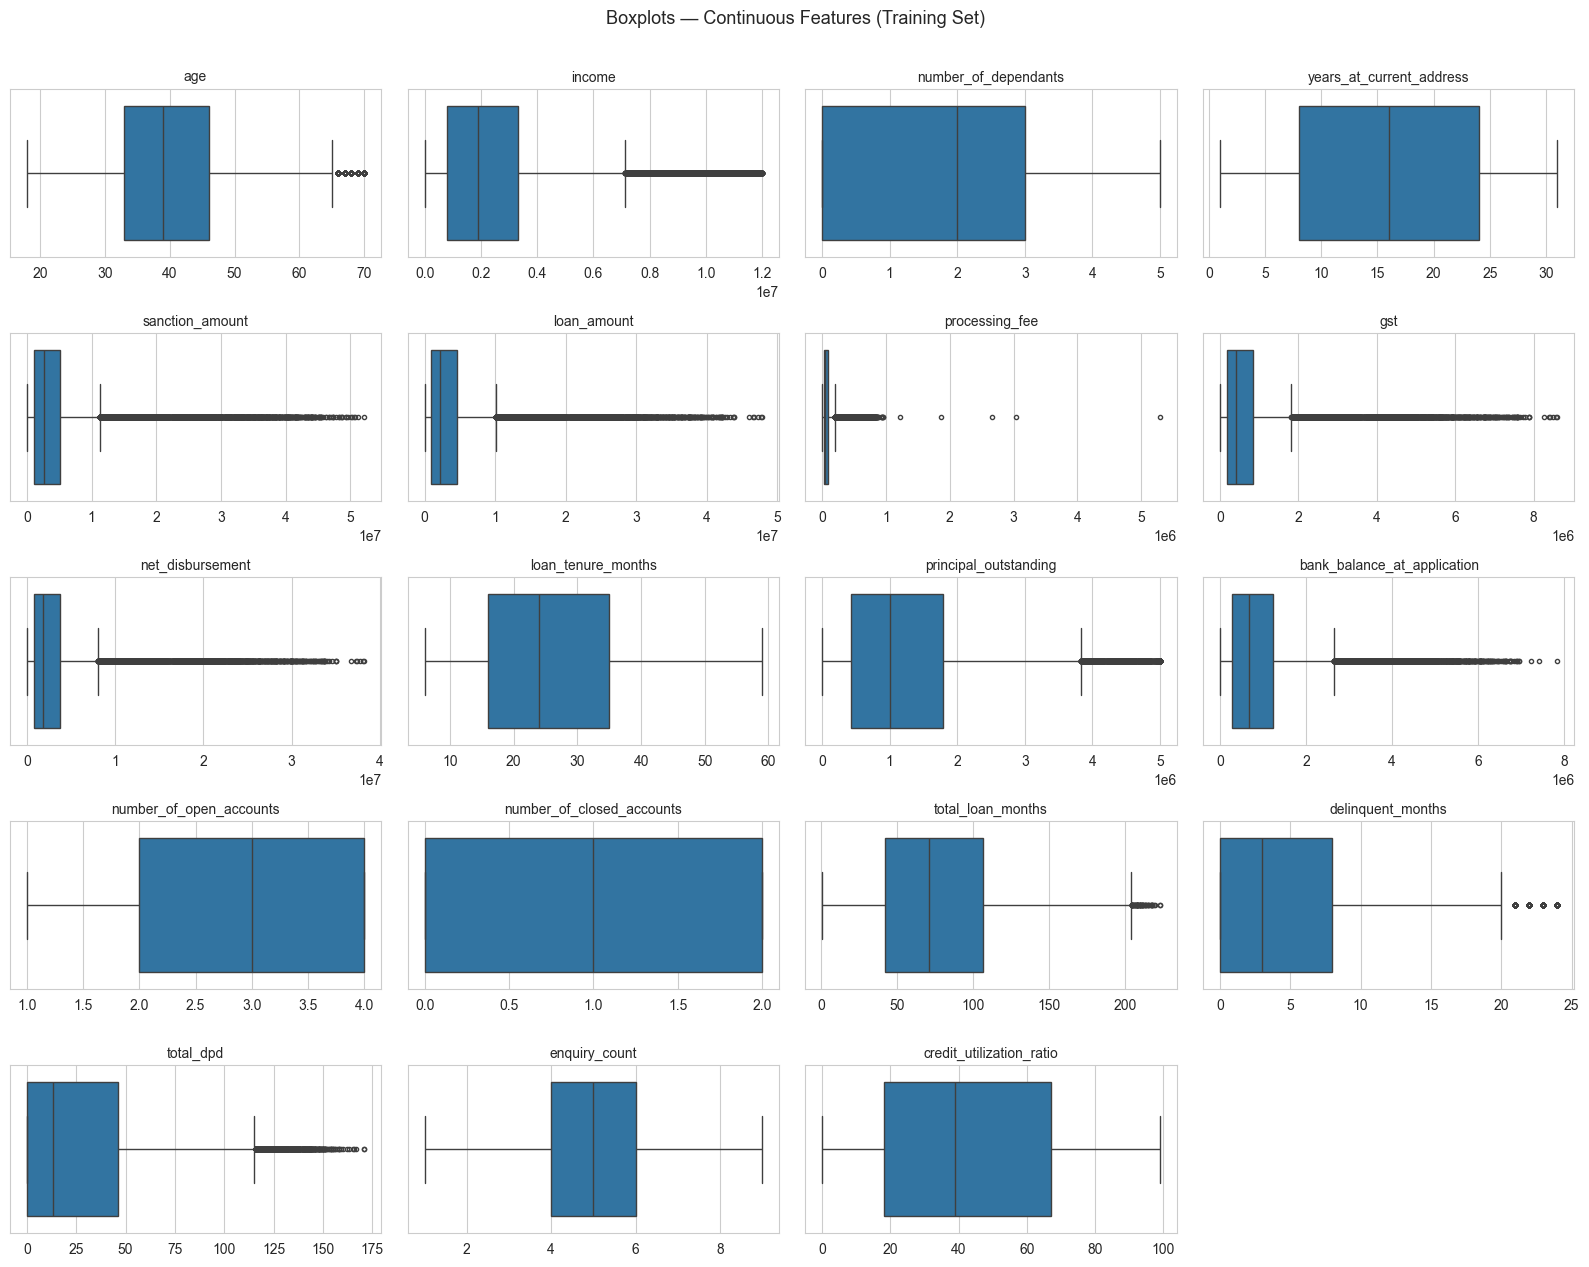

In [20]:
sns.set_style("whitegrid")

n_cols = 4
n_rows = (len(columns_continuous) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(columns_continuous):
    sns.boxplot(
        x=df_train[col],
        ax=axes[i],
        orient='h',
        fliersize=3,
        linewidth=1
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

# Remove empty subplots from the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots — Continuous Features (Training Set)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Continuous feature distributions — Histograms with KDE

Histograms overlaid with kernel density estimates reveal the distributional shape of each 
feature. Right-skewed distributions (e.g. `income`, `total_dpd`) may benefit from log 
transformation in future iterations. Bimodal distributions can indicate hidden sub-populations.


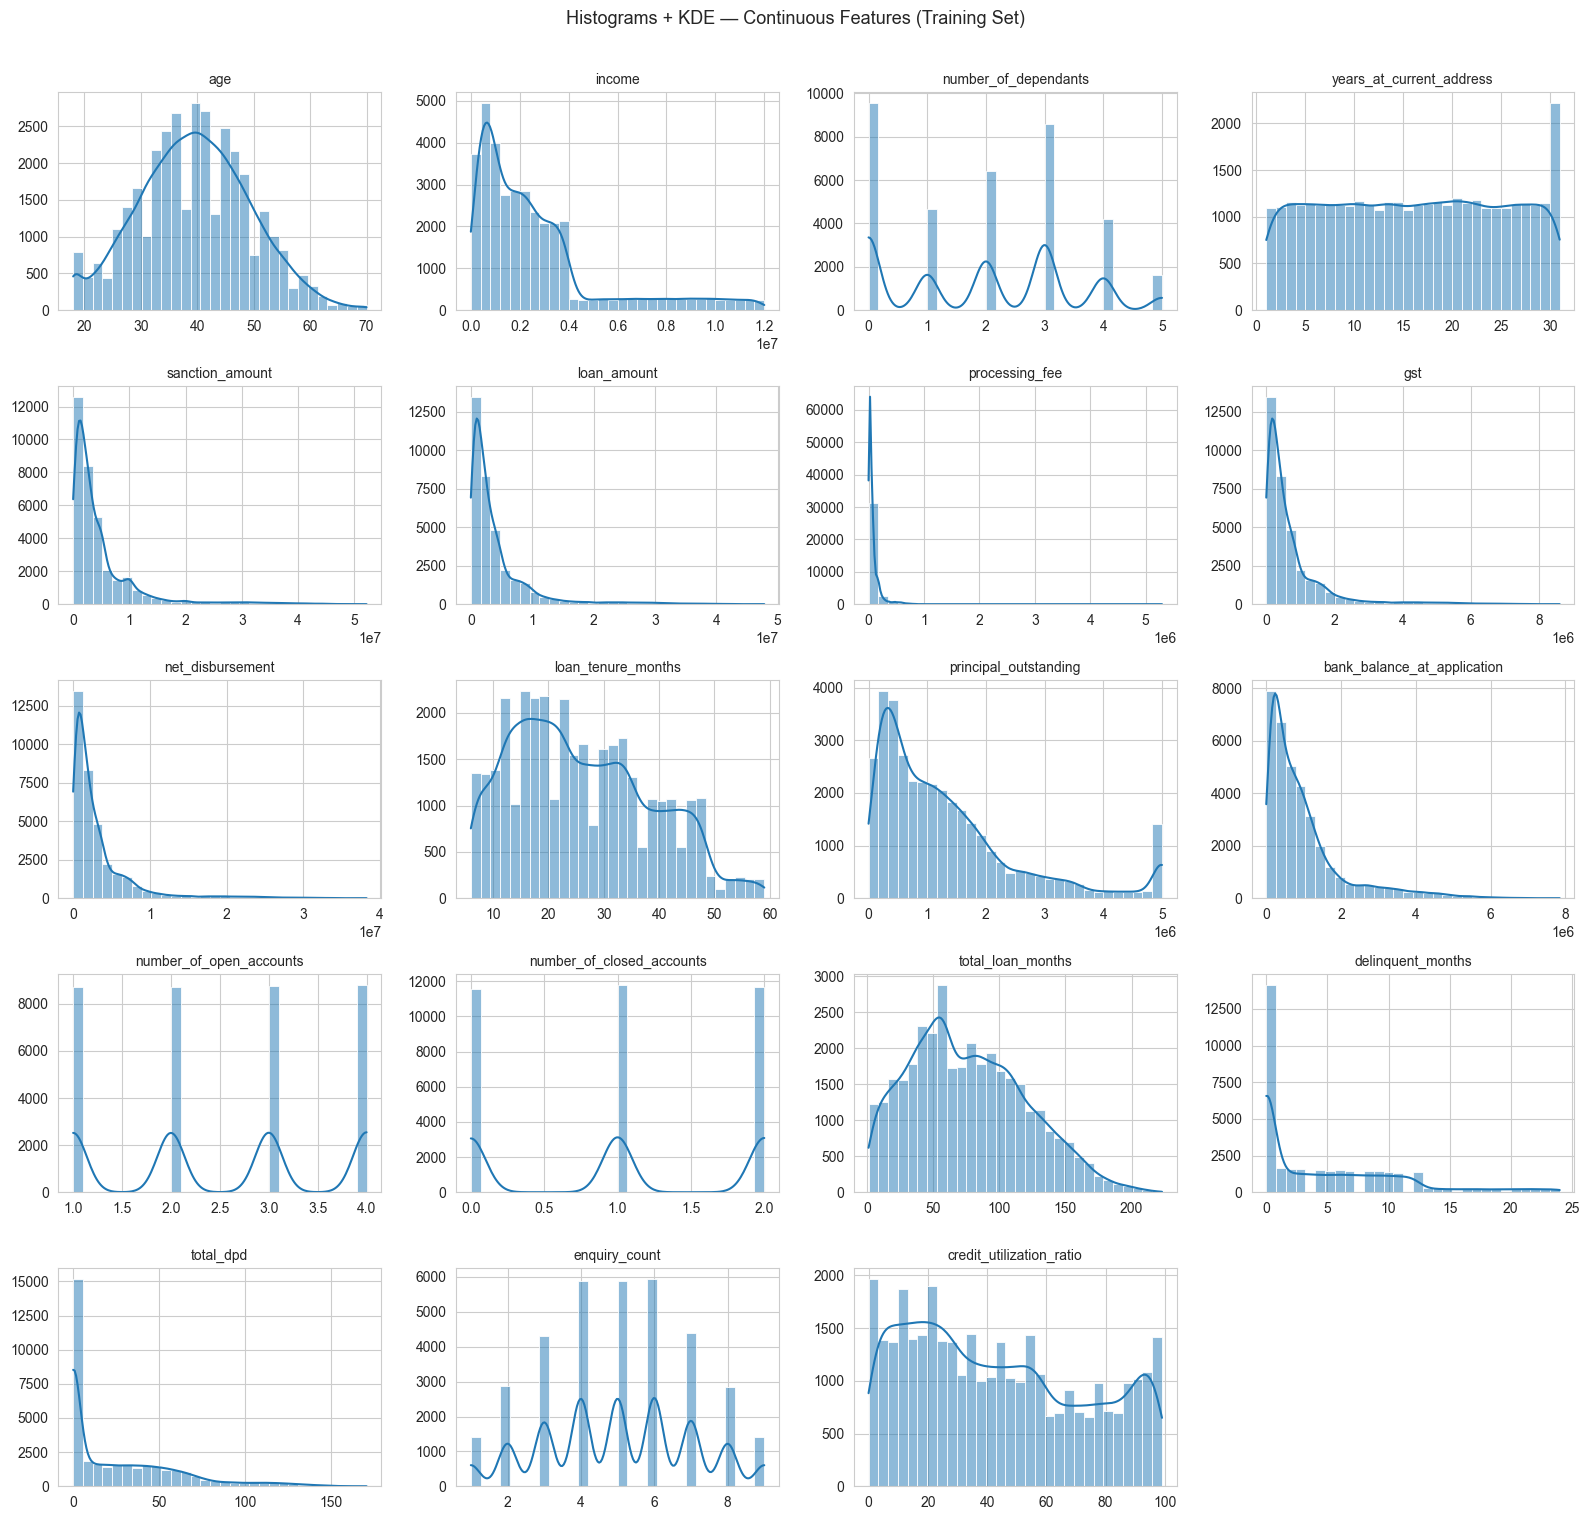

In [21]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(columns_continuous):
    sns.histplot(
        df_train[col],
        ax=axes[i],
        bins=30,
        kde=True  # Overlaid KDE curve helps assess distribution shape
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Histograms + KDE — Continuous Features (Training Set)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 5.4 Categorical feature inspection

For each categorical column, unique values and their counts are printed to:
- Detect typos or inconsistent labels (e.g. `'Personaal'` for `'Personal'`)
- Identify low-frequency categories that may need grouping
- Understand cardinality before choosing an encoding strategy


In [23]:
for col in columns_categorical:
    print(f"--- {col} ---")
    print(f"Unique values : {df_train[col].unique()}")
    print(f"Value counts  :\n{df_train[col].value_counts()}")
    print()

--- gender ---
Unique values : ['F' 'M']
Value counts  :
gender
M    21042
F    13958
Name: count, dtype: int64

--- marital_status ---
Unique values : ['Married' 'Single']
Value counts  :
marital_status
Married    19225
Single     15775
Name: count, dtype: int64

--- employment_status ---
Unique values : ['Self-Employed' 'Salaried']
Value counts  :
employment_status
Self-Employed    22456
Salaried         12544
Name: count, dtype: int64

--- residence_type ---
Unique values : ['Owned' 'Rented' 'Mortgage']
Value counts  :
residence_type
Owned       19753
Mortgage     8270
Rented       6977
Name: count, dtype: int64

--- city ---
Unique values : ['Mumbai' 'Kolkata' 'Lucknow' 'Chennai' 'Hyderabad' 'Jaipur' 'Pune'
 'Bangalore' 'Ahmedabad' 'Delhi']
Value counts  :
city
Mumbai       3578
Bangalore    3530
Ahmedabad    3525
Delhi        3520
Jaipur       3515
Kolkata      3492
Hyderabad    3488
Chennai      3471
Pune         3459
Lucknow      3422
Name: count, dtype: int64

--- state ---
Uni

---
## 6. Outlier Detection & Data Quality Checks

Rather than applying a blanket outlier removal rule (e.g. IQR capping), this section 
uses **domain knowledge** to identify anomalous records:

- **Processing fee > 3% of loan amount:** Lenders typically cap processing fees at 1–3% 
  of the sanctioned amount. Records exceeding this threshold are likely data entry errors 
  or fraudulent entries and are excluded.
- **GST > 18% of loan amount:** Under Indian GST law, the maximum applicable GST rate 
  on financial services is 18%. Records exceeding this are inconsistent.
- **Typo correction in `loan_purpose`:** The category `'Personaal'` is a misspelling of 
  `'Personal'` and must be corrected before encoding to avoid creating a spurious extra category.

> **Why domain-based rather than statistical outlier removal?**  
> Statistical methods (z-score, IQR) can remove legitimate extreme-but-valid records 
> (e.g. a genuinely high-income borrower). Business-rule violations, by contrast, 
> represent definitively invalid data regardless of statistical distribution.


In [24]:
# Descriptive statistics for processing_fee — check for anomalous values
df_train.processing_fee.describe()

count    3.500000e+04
mean     8.048791e+04
std      1.137501e+05
min      0.000000e+00
25%      1.926000e+04
50%      4.469000e+04
75%      9.258000e+04
max      5.293544e+06
Name: processing_fee, dtype: float64

In [25]:
# Identify records where processing fee exceeds 3% of the loan amount
# These violate standard lending business rules and are likely data errors
df_train[
    df_train.processing_fee / df_train.loan_amount > 0.03
][["loan_amount", "processing_fee"]]

,loan_amount,processing_fee
23981,2234000,2.669791e+06
28174,966000,1.214493e+06
47089,1738000,1.858965e+06
29305,2616000,3.036378e+06
9898,3626000,5.293544e+06


In [26]:
# Filter out business-rule-violating records from both train and test sets
# Using .copy() prevents SettingWithCopyWarning on subsequent column assignments
df_train_1 = df_train[df_train.processing_fee / df_train.loan_amount < 0.03].copy()
df_test_1  = df_test[df_test.processing_fee  / df_test.loan_amount  < 0.03].copy()

In [27]:
# Fix the 'Personaal' typo in loan_purpose — identical correction on both splits
df_train_1['loan_purpose'] = df_train_1['loan_purpose'].replace('Personaal', 'Personal')
df_test_1['loan_purpose']  = df_test_1['loan_purpose'].replace('Personaal', 'Personal')

In [28]:
# Verify no GST records exceed the 18% legal ceiling
# An empty result here confirms GST values are within the legal bound
df_train_1[
    df_train_1.gst / df_train_1.loan_amount > 0.18
][["loan_amount", "gst"]]

,loan_amount,gst


### 6.1 KDE comparison — Continuous features vs Default status

Overlaid KDE plots split by the `default` label reveal which features show separable 
distributions between defaulters (class 1) and non-defaulters (class 0). 
Strong visual separation (e.g. `total_dpd`, `delinquent_months`) indicates high 
predictive power and will be confirmed later by Information Value scores.


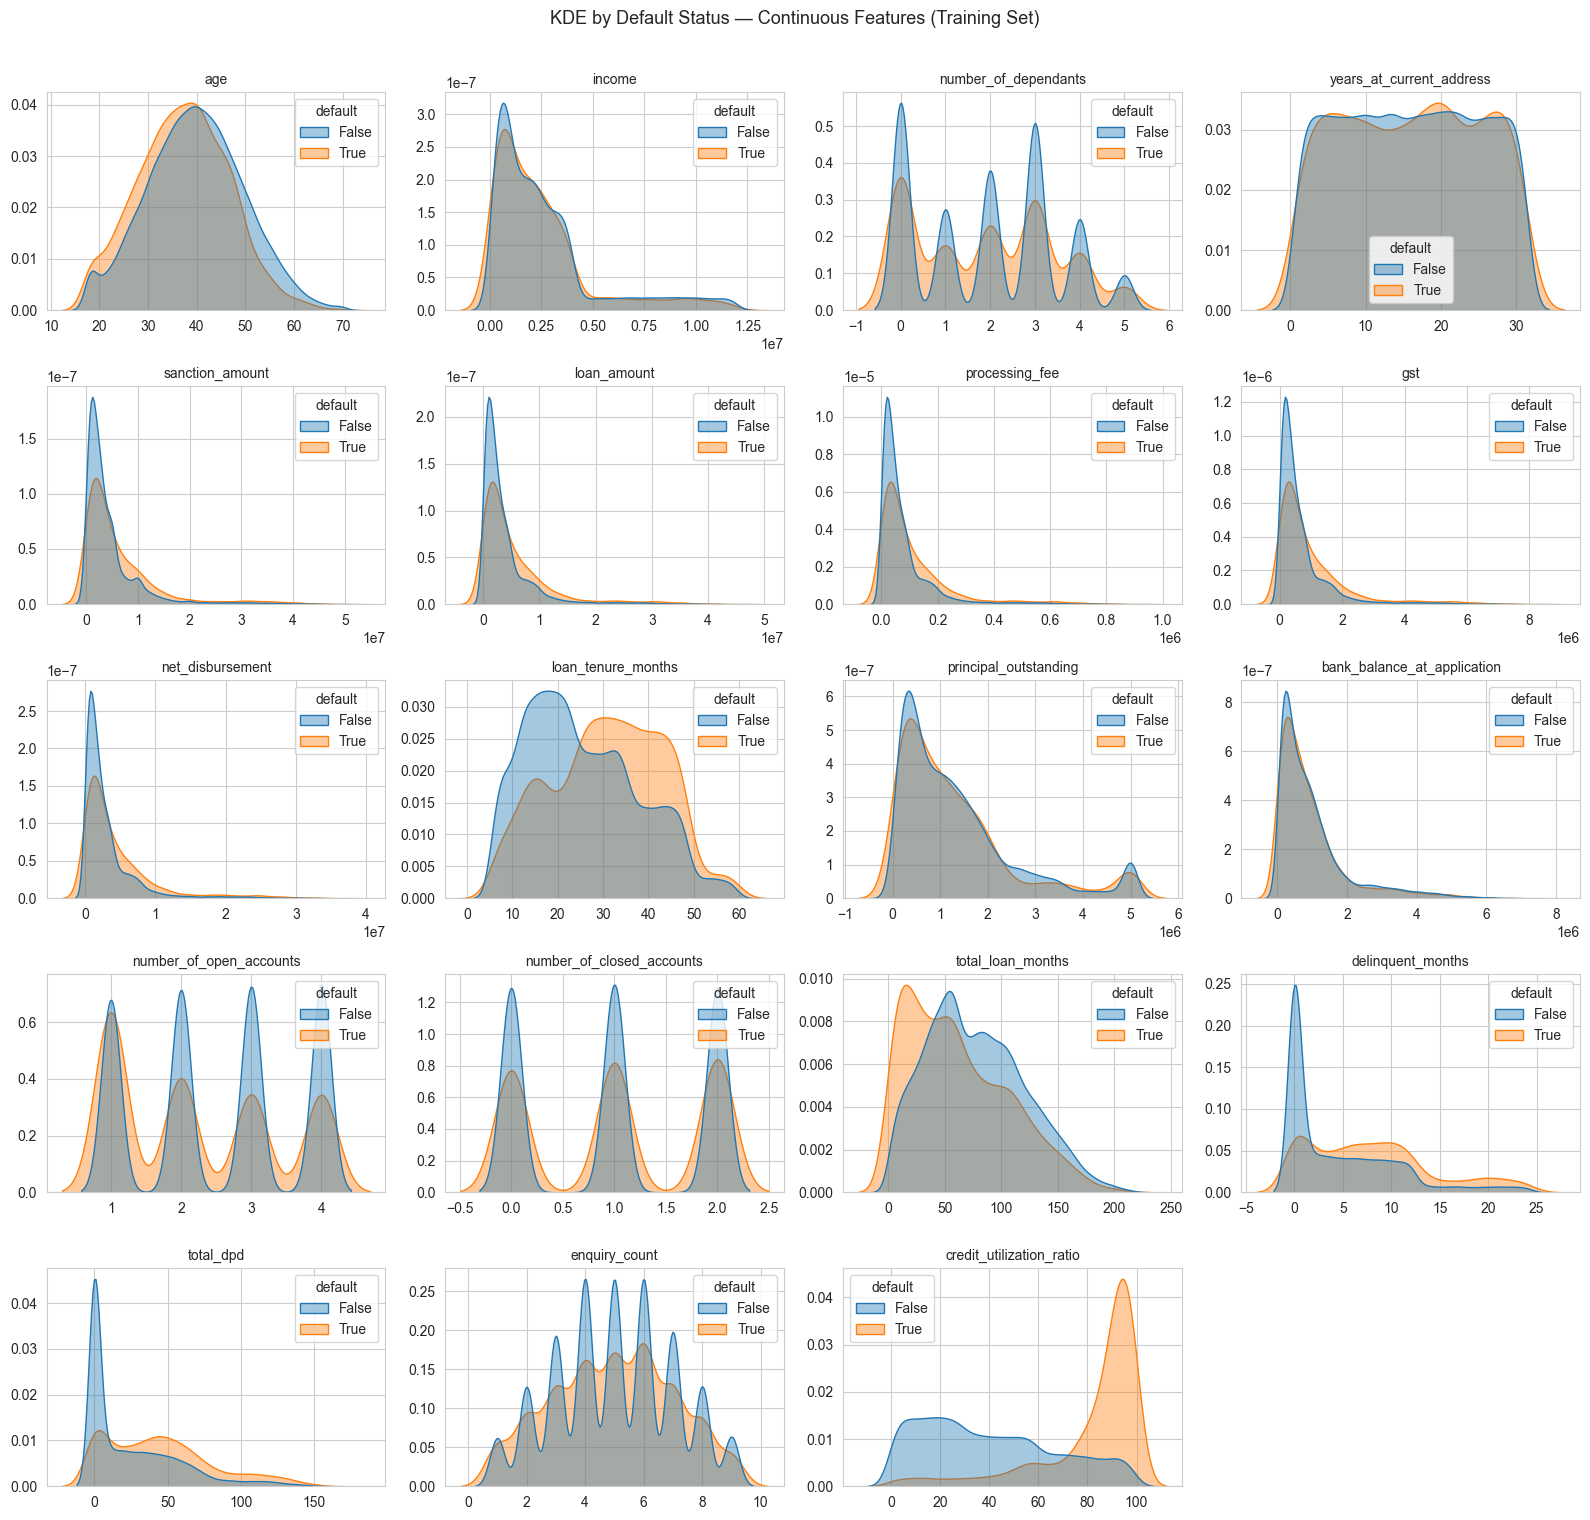

In [29]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(columns_continuous):
    sns.kdeplot(
        data=df_train_1,
        x=col,
        hue="default",
        ax=axes[i],
        fill=True,
        common_norm=False,  # Normalise each class independently so minority class is visible
        alpha=0.4
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("KDE by Default Status — Continuous Features (Training Set)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Feature Engineering

Three domain-informed ratio features are constructed to capture behaviours that raw 
features cannot express individually:

| Engineered Feature | Formula | Business Rationale |
|--------------------|---------|--------------------|
| `loan_to_income` | `loan_amount / income` | Measures debt burden relative to earnings. High values signal over-leverage. |
| `delinquent_ratio` | `(delinquent_months / total_loan_months) × 100` | Proportion of loan life spent in arrears. A more informative signal than raw delinquent months. |
| `avg_dpd_per_delinquency` | `total_dpd / delinquent_months` | Average severity of each missed payment. Distinguishes persistent mild delinquency from acute severe delinquency. |

> **Division-by-zero guard:** `avg_dpd_per_delinquency` replaces 0 in the denominator 
> with `NaN` before dividing, then fills the resulting `NaN` with 0. This correctly 
> assigns a DPD severity of 0 to customers who were never delinquent.

Each engineered feature is validated by plotting its KDE split by default status — 
confirming strong discriminative power before committing it to the feature matrix.


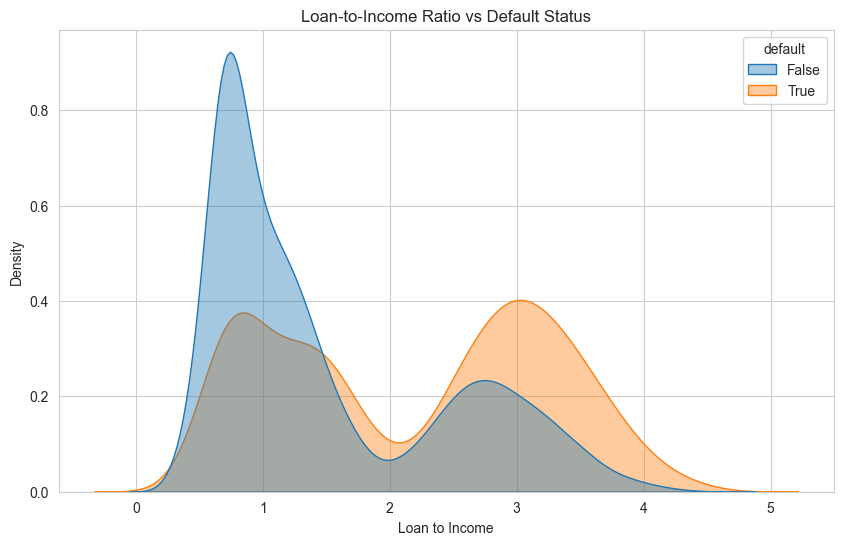

In [30]:
# Feature 1: Loan-to-Income ratio — debt burden relative to earnings
df_train_1["loan_to_income"] = round(df_train_1["loan_amount"] / df_train_1["income"], 3)

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_train_1, x="loan_to_income", hue="default",
    fill=True, common_norm=False, alpha=0.4
)
plt.title("Loan-to-Income Ratio vs Default Status")
plt.xlabel("Loan to Income")
plt.ylabel("Density")
plt.show()

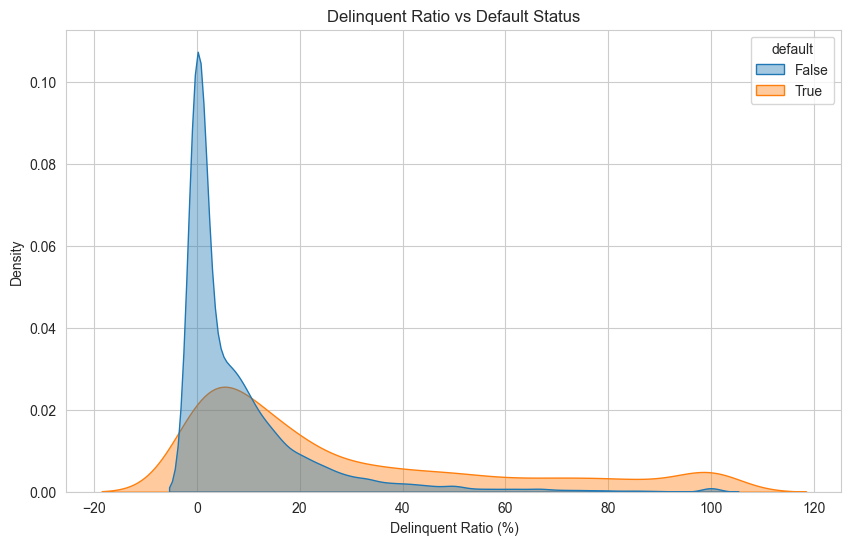

In [31]:
# Feature 2: Delinquent ratio — proportion of loan life spent in arrears (%)
df_train_1['delinquent_ratio'] = round(
    df_train_1['delinquent_months'] / df_train_1['total_loan_months'], 3
) * 100

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_train_1, x="delinquent_ratio", hue="default",
    fill=True, common_norm=False, alpha=0.4
)
plt.title("Delinquent Ratio vs Default Status")
plt.xlabel("Delinquent Ratio (%)")
plt.ylabel("Density")
plt.show()

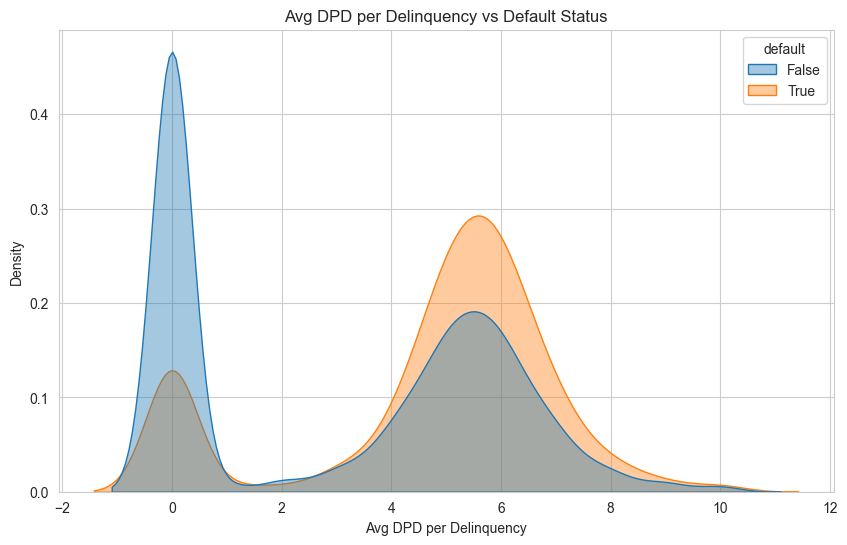

In [32]:
# Feature 3: Average DPD per delinquency — severity of each missed payment
# Guard: replace 0 delinquent_months with NaN to avoid division-by-zero,
# then fill NaN with 0 (customers with no delinquencies have 0 average DPD)
df_train_1["avg_dpd_per_delinquency"] = (
    df_train_1["total_dpd"] /
    df_train_1["delinquent_months"].replace(0, np.nan)
).fillna(0)

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_train_1, x="avg_dpd_per_delinquency", hue="default",
    fill=True, common_norm=False, alpha=0.4
)
plt.title("Avg DPD per Delinquency vs Default Status")
plt.xlabel("Avg DPD per Delinquency")
plt.ylabel("Density")
plt.show()

In [33]:
# Apply identical feature engineering to the test set
# All formulas use test-set columns only — no leakage
df_test_1["loan_to_income"] = round(df_test_1["loan_amount"] / df_test_1["income"], 3)

df_test_1['delinquent_ratio'] = round(
    df_test_1['delinquent_months'] / df_test_1['total_loan_months'], 3
) * 100

df_test_1["avg_dpd_per_delinquency"] = (
    df_test_1["total_dpd"] /
    df_test_1["delinquent_months"].replace(0, np.nan)
).fillna(0)

### 7.1 Drop source columns and identifiers

After creating ratio features from `loan_amount`, `income`, `total_loan_months`, 
`delinquent_months`, and `total_dpd`, the source columns are dropped. Retaining them 
alongside their ratios would reintroduce multicollinearity and make the VIF check in 
Section 8 less effective.

Date columns (`disbursal_date`, `installment_start_dt`) are also dropped — no date-based 
features were derived from them, and they cannot be used by scikit-learn models directly.


In [34]:
# Step 1: Drop identifier columns — these carry no predictive signal
df_train_2 = df_train_1.drop(['cust_id', 'loan_id'], axis=1)
df_test_2  = df_test_1.drop(['cust_id', 'loan_id'], axis=1)

In [35]:
# Step 2: Drop source columns used to construct engineered features,
# plus date columns that are not in a model-usable format
cols_to_drop = [
    "disbursal_date",       # Date — not encoded
    "installment_start_dt", # Date — not encoded
    "loan_amount",          # Replaced by loan_to_income
    "income",               # Replaced by loan_to_income
    "total_loan_months",    # Replaced by delinquent_ratio
    "delinquent_months",    # Replaced by delinquent_ratio and avg_dpd_per_delinquency
    "total_dpd",            # Replaced by avg_dpd_per_delinquency
]

df_train_3 = df_train_2.drop(cols_to_drop, axis=1)
df_test_3  = df_test_2.drop(cols_to_drop, axis=1)

---
## 8. Feature Selection — VIF & Correlation

**Why VIF?** Variance Inflation Factor measures how much the variance of a regression 
coefficient is inflated due to collinearity with other predictors. A VIF > 5–10 indicates 
problematic multicollinearity:

- It makes coefficient estimates unstable in Logistic Regression.
- It means the feature carries redundant information already captured by others.
- It artificially inflates the feature matrix, increasing model complexity without benefit.

**Workflow:**
1. Scale numeric features to [0, 1] with `MinMaxScaler` — VIF is sensitive to scale differences.
2. Compute VIF for all numeric features.
3. Drop features with VIF above threshold (iteratively or in one pass based on domain knowledge).
4. Recompute VIF to confirm remaining features are within acceptable range.

> `zipcode` is excluded from scaling and VIF: although stored as a numeric type, 
> it is a categorical identifier (postal code) and should not be treated as a continuous variable.


In [36]:
def calculate_vif(data):
    """Compute Variance Inflation Factor for all columns in a numeric DataFrame.
    
    Parameters
    ----------
    data : pd.DataFrame
        DataFrame containing only numeric features (no categorical columns).
    
    Returns
    -------
    pd.DataFrame
        Two-column table with 'Variable' and 'VIF' for each input feature.
        VIF > 10 indicates high multicollinearity; these features should be dropped.
    """
    vif_df = pd.DataFrame()
    vif_df['Variable'] = data.columns
    vif_df['VIF'] = [
        variance_inflation_factor(data.values, i)
        for i in range(data.shape[1])
    ]
    return vif_df

In [37]:
X_train = df_train_3.drop('default', axis=1)
y_train = df_train_3['default']

# Identify numeric columns to scale, excluding zipcode (categorical despite int dtype)
cols_to_scale = X_train.select_dtypes(include=["int64", "float64"]).columns
cols_to_scale = cols_to_scale.drop('zipcode')

# Fit scaler on training set ONLY — prevents test-set statistics from influencing scaling
scaler = MinMaxScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

In [38]:
# Apply the SAME scaler (fitted on train) to the test set — no re-fitting
X_test = df_test_3.drop('default', axis=1)
y_test = df_test_3['default']
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [39]:
# First VIF pass — before dropping any features
calculate_vif(X_train[cols_to_scale])

C:\Users\soham\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variable,VIF
0,age,5.560996
1,number_of_dependants,2.720726
2,years_at_current_address,3.367325
3,sanction_amount,101.788932
4,processing_fee,inf
5,gst,inf
6,net_disbursement,inf
7,loan_tenure_months,6.195918
8,principal_outstanding,16.272307
9,bank_balance_at_application,9.311471


In [40]:
# Drop features with high VIF (multicollinear loan financial features)
# sanction_amount, processing_fee, gst, net_disbursement, and principal_outstanding
# are all derived from or highly correlated with loan_amount (already dropped),
# causing severe redundancy
features_to_drop_vif = [
    'sanction_amount',
    'processing_fee',
    'gst',
    'net_disbursement',
    'principal_outstanding'
]

X_train_1 = X_train.drop(features_to_drop_vif, axis=1)
X_test_1  = X_test.drop(features_to_drop_vif, axis=1)
numeric_columns = X_train_1.select_dtypes(include=["int64", "float64"]).columns

In [41]:
# Second VIF pass — confirm remaining features are below the collinearity threshold
vif_df = calculate_vif(X_train_1[numeric_columns])
vif_df

,Variable,VIF
0,age,5.534863
1,number_of_dependants,2.728201
2,years_at_current_address,3.453529
3,zipcode,5.601405
4,loan_tenure_months,6.050137
5,bank_balance_at_application,1.810351
6,number_of_open_accounts,4.359415
7,number_of_closed_accounts,2.390685
8,enquiry_count,6.429720
9,credit_utilization_ratio,2.948742


In [42]:
# Store the list of retained numeric features for reference
selected_numeric_feature = vif_df.Variable.values
selected_numeric_feature

array(['age', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'enquiry_count', 'credit_utilization_ratio', 'loan_to_income',
       'delinquent_ratio', 'avg_dpd_per_delinquency'], dtype=object)

### 8.1 Correlation Heatmap

A Pearson correlation heatmap confirms pairwise linear relationships between the remaining 
numeric features and the target variable. Cells near ±1 indicate strong correlation; cells 
near 0 indicate independence. This supplements VIF by showing the direction of association.


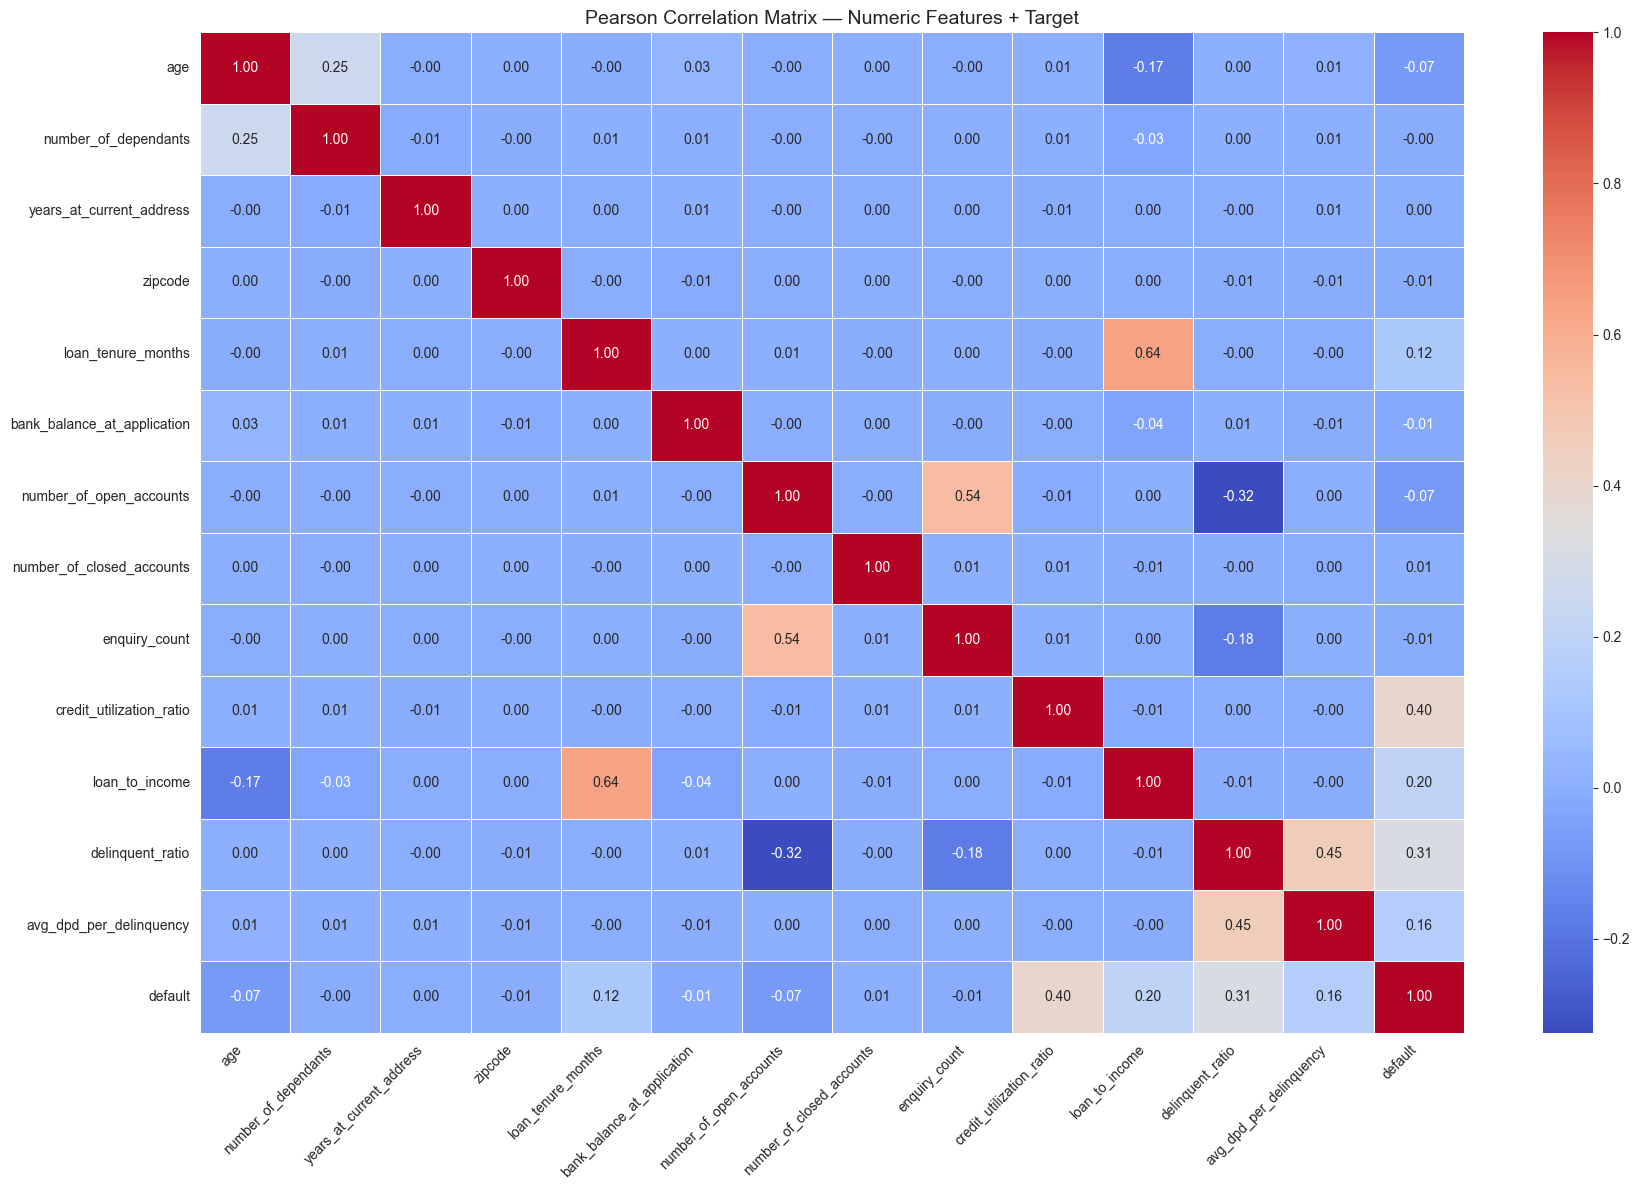

In [43]:
plt.figure(figsize=(18, 12))
sns.heatmap(
    df_train_3[list(numeric_columns) + ['default']].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Pearson Correlation Matrix — Numeric Features + Target", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---
## 9. Feature Selection — WoE & Information Value

**Weight of Evidence (WoE)** and **Information Value (IV)** are widely used in credit 
risk modelling for feature selection. Unlike correlation, they:

- Work for both categorical and continuous features (the latter requires binning).
- Capture non-linear monotonic relationships with the binary target.
- Provide a standardised, interpretable measure of predictive power.

**IV interpretation guide:**

| IV Range | Predictive Power |
|----------|------------------|
| < 0.02 | Useless — excluded |
| 0.02 – 0.1 | Weak |
| 0.1 – 0.3 | Medium |
| 0.3 – 0.5 | Strong |
| > 0.5 | Suspicious (possible leakage) |

**Implementation details:**
- Continuous features are binned into 10 equal-width bins using `pd.cut` before WoE calculation.
- Features with IV ≤ 0.02 are excluded — they contribute noise rather than signal.
- WoE and IV are computed using **training data only**, then applied as a filter to both splits.


In [44]:
def calculate_woe_iv(df, feature, target):
    """Compute Weight of Evidence (WoE) and Information Value (IV) for a feature.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the feature and target columns.
    feature : str or pd.Series
        Column name (for categoricals) or a pre-binned Series (for continuous features).
    target : str
        Name of the binary target column (1 = event/default, 0 = non-event).
    
    Returns
    -------
    woe : pd.Series
        WoE value for each category/bin.
    iv : float
        Total Information Value for the feature. Higher = more predictive.
    
    Notes
    -----
    WoE = ln(Distribution of Events / Distribution of Non-Events) per bin.
    IV  = sum over bins of (Dist Events - Dist Non-Events) * WoE.
    """
    grouped = df.groupby(feature)[target].agg(['count', 'sum'])
    grouped['non_default'] = grouped['count'] - grouped['sum']
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'default'})

    grouped['approve_ratio']     = grouped['default']     / grouped['default'].sum()
    grouped['non_approve_ratio'] = grouped['non_default'] / grouped['non_default'].sum()

    grouped['woe'] = np.log(grouped['approve_ratio'] / grouped['non_approve_ratio'])
    grouped['iv']  = (
        (grouped['approve_ratio'] - grouped['non_approve_ratio']) * grouped['woe']
    )
    return grouped['woe'], grouped['iv'].sum()

In [45]:
# Compute IV for every feature and retain those above the 0.02 threshold
df_temp = pd.concat([X_train_1, y_train], axis=1)
best_columns = []

for i in X_train_1.columns:
    if X_train_1[i].dtype == 'object':
        # Categorical: compute WoE/IV directly on raw categories
        woe, iv = calculate_woe_iv(df_temp, i, 'default')
    else:
        # Continuous: bin into 10 equal-width bins before computing WoE/IV
        X_binned = pd.cut(X_train_1[i], bins=10, labels=False)
        woe, iv  = calculate_woe_iv(df_temp, X_binned, 'default')

    if iv > 0.02:
        best_columns.append(i)

    print(f"\nFeature : {i}")
    print(f"IV      : {iv:.4f}  {'✓ Selected' if iv > 0.02 else '✗ Dropped (IV ≤ 0.02)'}")
    print("WoE per bin/category:")
    print(woe)
    print("-" * 50)


Feature : age
IV      : 0.0829  ✓ Selected
WoE per bin/category:
age
0    0.422811
1    0.321179
2    0.172350
3    0.060773
4   -0.007049
5   -0.076894
6   -0.566733
7   -0.829284
8   -0.691585
9   -1.046810
Name: woe, dtype: float64
--------------------------------------------------

Feature : gender
IV      : 0.0005  ✗ Dropped (IV ≤ 0.02)
WoE per bin/category:
gender
F    0.028439
M   -0.019237
Name: woe, dtype: float64
--------------------------------------------------

Feature : marital_status
IV      : 0.0008  ✗ Dropped (IV ≤ 0.02)
WoE per bin/category:
marital_status
Married   -0.025544
Single     0.030414
Name: woe, dtype: float64
--------------------------------------------------

Feature : employment_status
IV      : 0.0033  ✗ Dropped (IV ≤ 0.02)
WoE per bin/category:
employment_status
Salaried         0.074628
Self-Employed   -0.043788
Name: woe, dtype: float64
--------------------------------------------------

Feature : number_of_dependants
IV      : 0.0016  ✗ Dropped (IV

In [46]:
print(f"Selected {len(best_columns)} features based on IV > 0.02 threshold:")
print(best_columns)

Selected 10 features based on IV > 0.02 threshold:
['age', 'residence_type', 'loan_purpose', 'loan_type', 'loan_tenure_months', 'number_of_open_accounts', 'credit_utilization_ratio', 'loan_to_income', 'delinquent_ratio', 'avg_dpd_per_delinquency']


In [47]:
# Apply IV-based feature filter to both train and test feature matrices
X_train_reduced = X_train_1[best_columns]
X_test_reduced  = X_test_1[best_columns]

---
## 10. Encoding & Final Feature Matrix

**One-Hot Encoding with `drop_first=True`:**

Remaining categorical features are one-hot encoded to convert them into a numeric 
representation compatible with all sklearn models.

`drop_first=True` removes the first dummy variable for each categorical feature. 
This prevents the **dummy variable trap** (perfect multicollinearity where one 
dummy column is a linear combination of the others), which is especially important 
for Logistic Regression.

> The same `pd.get_dummies` call is applied independently to train and test. 
> Because the categorical values were cleaned and standardised earlier, 
> both splits produce identical column sets.


In [48]:
# One-hot encode categorical features; drop_first=True avoids dummy variable trap
X_train_encoded = pd.get_dummies(X_train_reduced, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test_reduced,  drop_first=True)

In [49]:
# Inspect final feature matrix — confirms shape and column names before modelling
print(f"Final training feature matrix: {X_train_encoded.shape}")
X_train_encoded.head()

Final training feature matrix: (34989, 13)


,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquent_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
35147,0.673077,0.377358,1.000000,0.474747,0.200703,0.046,0.60,True,False,True,False,False,False
15711,0.519231,0.358491,0.000000,0.969697,0.635170,1.000,0.55,True,False,False,True,False,False
5304,0.365385,0.188679,1.000000,0.131313,0.015709,0.000,0.00,False,True,False,False,True,True
24708,0.634615,0.113208,0.666667,0.333333,0.124033,0.000,0.00,False,False,False,False,False,False
33512,0.711538,0.773585,0.666667,0.929293,0.231887,0.000,0.00,True,False,True,False,False,False


---
## 11. Baseline Modelling

Four models are trained with default (or lightly constrained) hyperparameters to 
establish a performance baseline. The purpose is **comparative**, not final:

| Model | Why included |
|-------|--------------|
| Logistic Regression | Linear baseline; interpretable coefficients; fast to train |
| Random Forest | Ensemble baseline; handles non-linearity; built-in feature importance |
| XGBoost | Gradient boosting; typically strong out-of-the-box on tabular data |
| Decision Tree | Shallow tree baseline; highly interpretable; prone to overfitting |

**Evaluation metric: Classification Report**  
Reporting precision, recall, and F1-score per class is more informative than accuracy 
on an imbalanced dataset. The minority class (default = 1) recall is the primary concern 
in credit risk: false negatives (missed defaults) are far more costly than false positives.

> **Note on class imbalance:** All baselines are trained on the imbalanced training set. 
> Systematically poor recall on the minority class here motivates the SMOTETomek step in Section 13.


In [50]:
# Baseline 1: Logistic Regression — default hyperparameters
model_lc = LogisticRegression(random_state=42)
model_lc.fit(X_train_encoded, y_train)
print("=" * 50)
print("Logistic Regression — Baseline")
print("=" * 50)
print(classification_report(y_test, model_lc.predict(X_test_encoded)))

Logistic Regression — Baseline
              precision    recall  f1-score   support

       False       0.97      0.99      0.98     13707
        True       0.84      0.71      0.77      1289

    accuracy                           0.96     14996
   macro avg       0.91      0.85      0.88     14996
weighted avg       0.96      0.96      0.96     14996



In [51]:
# Baseline 2: Random Forest — default hyperparameters
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_encoded, y_train)
print("=" * 50)
print("Random Forest — Baseline")
print("=" * 50)
print(classification_report(y_test, model_rf.predict(X_test_encoded)))

Random Forest — Baseline
              precision    recall  f1-score   support

       False       0.97      0.99      0.98     13707
        True       0.86      0.71      0.78      1289

    accuracy                           0.96     14996
   macro avg       0.91      0.85      0.88     14996
weighted avg       0.96      0.96      0.96     14996



In [52]:
# Baseline 3: XGBoost — default hyperparameters
model_xgb = XGBClassifier(random_state=42)
model_xgb.fit(X_train_encoded, y_train)
print("=" * 50)
print("XGBoost — Baseline")
print("=" * 50)
print(classification_report(y_test, model_xgb.predict(X_test_encoded)))

XGBoost — Baseline
              precision    recall  f1-score   support

       False       0.98      0.98      0.98     13707
        True       0.82      0.75      0.78      1289

    accuracy                           0.96     14996
   macro avg       0.90      0.87      0.88     14996
weighted avg       0.96      0.96      0.96     14996



In [53]:
# Baseline 4: Decision Tree — constrained depth to prevent pure memorisation
# max_depth=5, min_samples_leaf=20, min_samples_split=50 applied as light regularisation
model_dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_leaf=20,
    min_samples_split=50
)
model_dt.fit(X_train_encoded, y_train)
print("=" * 50)
print("Decision Tree — Constrained Baseline")
print("=" * 50)
print(classification_report(y_test, model_dt.predict(X_test_encoded)))

Decision Tree — Constrained Baseline
              precision    recall  f1-score   support

       False       0.97      0.98      0.98     13707
        True       0.79      0.64      0.71      1289

    accuracy                           0.95     14996
   macro avg       0.88      0.81      0.84     14996
weighted avg       0.95      0.95      0.95     14996



---
## 12. Hyperparameter Tuning — RandomizedSearchCV

**Why RandomizedSearchCV instead of GridSearchCV?**  
Grid search exhaustively evaluates all parameter combinations — prohibitively expensive 
for models like XGBoost with 7+ hyperparameters. Randomised search samples a fixed number 
of combinations (`n_iter`) from the defined distributions, providing a good trade-off 
between coverage and compute cost. Research (Bergstra & Bengio, 2012) shows randomised 
search finds comparably good solutions in a fraction of the time.

**Scoring metric: F1**  
F1 is chosen over accuracy because of class imbalance. It balances precision and recall, 
penalising models that achieve high accuracy by simply predicting the majority class.

**Cross-validation: 5-fold**  
5-fold CV on the training set provides a robust estimate of generalisation performance 
across different data splits, reducing variance in the hyperparameter selection.


In [54]:
# Tuning: Logistic Regression
# C controls regularisation strength (lower = more regularised)
# Searching over log-scale for C (common practice for regularisation parameters)
lr = LogisticRegression(random_state=42)

param_lr = {
    'C':            np.logspace(-4, 4, 50),  # Log-uniform search over 8 orders of magnitude
    'penalty':      ['l1', 'l2'],             # L1 = Lasso (sparse); L2 = Ridge (shrinkage)
    'solver':       ['liblinear'],            # liblinear supports both L1 and L2
    'class_weight': [None, 'balanced']        # 'balanced' up-weights minority class
}

rs_lr = RandomizedSearchCV(
    lr,
    param_distributions=param_lr,
    n_iter=30,          # Sample 30 combinations from the search space
    scoring='f1',
    cv=5,
    n_jobs=-1,          # Use all available CPU cores
    random_state=42
)
rs_lr.fit(X_train_encoded, y_train)

print("Best Params:", rs_lr.best_params_)
print("Best CV F1 :", rs_lr.best_score_)
best_lr = rs_lr.best_estimator_
print("\nTest Set Performance:")
print(classification_report(y_test, best_lr.predict(X_test_encoded)))

Best Params: {'solver': 'liblinear', 'penalty': 'l2', 'class_weight': None, 'C': np.float64(1526.4179671752302)}
Best CV F1 : 0.7599648138848473

Test Set Performance:
              precision    recall  f1-score   support

       False       0.98      0.99      0.98     13707
        True       0.83      0.73      0.78      1289

    accuracy                           0.96     14996
   macro avg       0.90      0.86      0.88     14996
weighted avg       0.96      0.96      0.96     14996



In [55]:
# Tuning: Decision Tree
dt = DecisionTreeClassifier(random_state=42)

param_dt = {
    'max_depth':        [3, 5, 7, 10, 15, 20, None],
    'min_samples_split':[2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'criterion':        ['gini', 'entropy'],    # Impurity measure for splits
    'class_weight':     [None, 'balanced']
}

rs_dt = RandomizedSearchCV(
    dt, param_dt,
    n_iter=50, scoring='f1', cv=5,
    n_jobs=-1, random_state=42
)
rs_dt.fit(X_train_encoded, y_train)

print("Best Params:", rs_dt.best_params_)
print("Best CV F1 :", rs_dt.best_score_)
best_dt = rs_dt.best_estimator_
print("\nTest Set Performance:")
print(classification_report(y_test, best_dt.predict(X_test_encoded)))

Best Params: {'min_samples_split': 20, 'min_samples_leaf': 20, 'max_depth': 20, 'criterion': 'gini', 'class_weight': None}
Best CV F1 : 0.7300628763272923

Test Set Performance:
              precision    recall  f1-score   support

       False       0.97      0.98      0.98     13707
        True       0.78      0.72      0.75      1289

    accuracy                           0.96     14996
   macro avg       0.88      0.85      0.86     14996
weighted avg       0.96      0.96      0.96     14996



In [56]:
# Tuning: XGBoost — 7-parameter search space
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

param_xgb = {
    'n_estimators':    [100, 200, 300, 500],        # Number of boosting rounds
    'max_depth':       [3, 4, 5, 6, 8, 10],         # Tree depth (complexity control)
    'learning_rate':   [0.01, 0.03, 0.05, 0.1, 0.2],# Shrinkage parameter
    'subsample':       [0.6, 0.8, 1.0],             # Row subsampling per tree
    'colsample_bytree':[0.6, 0.8, 1.0],             # Feature subsampling per tree
    'min_child_weight':[1, 3, 5, 7],                # Minimum leaf node weight
    'gamma':           [0, 0.1, 0.3, 0.5]           # Minimum split loss reduction
}

rs_xgb = RandomizedSearchCV(
    xgb, param_xgb,
    n_iter=50, scoring='f1', cv=5,
    n_jobs=-1, random_state=42
)
rs_xgb.fit(X_train_encoded, y_train)

print("Best Params:", rs_xgb.best_params_)
print("Best CV F1 :", rs_xgb.best_score_)
best_xgb = rs_xgb.best_estimator_
print("\nTest Set Performance:")
print(classification_report(y_test, best_xgb.predict(X_test_encoded)))

Best Params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.8}
Best CV F1 : 0.7786404991223247

Test Set Performance:
              precision    recall  f1-score   support

       False       0.98      0.99      0.98     13707
        True       0.84      0.75      0.79      1289

    accuracy                           0.97     14996
   macro avg       0.91      0.87      0.89     14996
weighted avg       0.97      0.97      0.97     14996



---
## 13. Class Imbalance Handling — SMOTETomek

The target variable `default` is heavily imbalanced (many more non-defaulters than 
defaulters). This causes classifiers to bias toward the majority class, producing high 
accuracy but poor recall on the minority (default) class — the most consequential 
prediction in credit risk.

**SMOTETomek** is a hybrid resampling strategy combining:

| Component | Mechanism | Effect |
|-----------|-----------|--------|
| **SMOTE** (Synthetic Minority Oversampling Technique) | Generates synthetic minority class samples by interpolating between existing minority instances in feature space | Increases minority class size |
| **Tomek Links** | Identifies majority class samples that are borderline (nearest neighbour of a minority sample) and removes them | Cleans class boundary, reduces majority class near the decision boundary |

**Why not SMOTE alone?** SMOTE can introduce noisy synthetic samples near the class 
boundary. Tomek link removal acts as a denoising step, producing a cleaner decision boundary.

**Critical:** SMOTETomek is applied **only to the training set**. Applying it to the 
test set would produce an unrealistic class distribution and invalidate the evaluation.


In [57]:
# Fit SMOTETomek on training data ONLY
# The test set retains its original (real-world) class distribution for evaluation
smote_tomek = SMOTETomek(random_state=42)
X_train_smote, y_train_smote = smote_tomek.fit_resample(X_train_encoded, y_train)

print("Original training class distribution:")
print(y_train.value_counts())
print("\nResampled training class distribution:")
print(y_train_smote.value_counts())

Original training class distribution:
default
False    31981
True      3008
Name: count, dtype: int64

Resampled training class distribution:
default
False    31911
True     31911
Name: count, dtype: int64


### 13.1 Re-evaluate models on resampled data

Logistic Regression and XGBoost are re-trained on the SMOTETomek-balanced training set 
and evaluated on the **original** (unmodified) test set. An improvement in minority-class 
recall confirms that the resampling is effective without harming precision too severely.


In [58]:
# Logistic Regression on SMOTETomek data
model_lc_smote = LogisticRegression(random_state=42)
model_lc_smote.fit(X_train_smote, y_train_smote)
print("=" * 50)
print("Logistic Regression — After SMOTETomek")
print("=" * 50)
print(classification_report(y_test, model_lc_smote.predict(X_test_encoded)))

# XGBoost on SMOTETomek data
model_xgb_smote = XGBClassifier(random_state=42)
model_xgb_smote.fit(X_train_smote, y_train_smote)
print("=" * 50)
print("XGBoost — After SMOTETomek")
print("=" * 50)
print(classification_report(y_test, model_xgb_smote.predict(X_test_encoded)))

Logistic Regression — After SMOTETomek
              precision    recall  f1-score   support

       False       0.99      0.93      0.96     13707
        True       0.56      0.94      0.70      1289

    accuracy                           0.93     14996
   macro avg       0.78      0.94      0.83     14996
weighted avg       0.96      0.93      0.94     14996

XGBoost — After SMOTETomek
              precision    recall  f1-score   support

       False       0.98      0.97      0.98     13707
        True       0.73      0.83      0.78      1289

    accuracy                           0.96     14996
   macro avg       0.86      0.90      0.88     14996
weighted avg       0.96      0.96      0.96     14996



---
## 14. Bayesian Hyperparameter Optimisation — Optuna

**Why Optuna over RandomizedSearchCV for the final tuning step?**

RandomizedSearchCV samples hyperparameter combinations **independently** — each trial 
has no awareness of previous results. Optuna uses a **Tree-structured Parzen Estimator 
(TPE)** — a Bayesian optimisation algorithm that:

1. Builds a probabilistic model of which hyperparameter regions yield high scores.
2. Focuses subsequent trials on promising regions, converging faster than random search.
3. Supports **trial pruning** — detecting and stopping unpromising trials early.

**Logistic Regression Optuna study:**
- 50 trials, maximising macro F1 on 5-fold CV over the SMOTETomek training set.
- Solver–penalty compatibility enforced via `optuna.TrialPruned()` (e.g. `lbfgs` does not 
  support L1 regularisation — invalid combinations are skipped rather than crashing).
- **Best CV macro F1: 0.9776** (trial 24 of 50).

**XGBoost Optuna study:**
- 50 trials, maximising macro F1 on 3-fold CV (3-fold used for speed given XGBoost's 
  higher training cost vs. Logistic Regression).
- **Best CV macro F1: 0.9457** (trial 42 of 50).

Logistic Regression outperforms XGBoost in the Optuna studies, suggesting the selected 
features after VIF + IV filtering are largely linearly separable after resampling.


In [59]:
# Optuna objective function for Logistic Regression
def objective(trial):
    """Optuna objective: maximise macro F1 for Logistic Regression on SMOTETomek data.
    
    Solver-penalty compatibility is enforced by pruning invalid combinations:
    - 'lbfgs' and 'newton-cg' solvers do not support L1 penalty.
    - Pruning rather than raising an exception allows Optuna to log the trial
      and continue cleanly.
    """
    solver = trial.suggest_categorical('solver', ['liblinear', 'lbfgs', 'saga', 'newton-cg'])
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])

    # Prune incompatible solver-penalty combinations
    if solver in ['lbfgs', 'newton-cg'] and penalty == 'l1':
        raise optuna.TrialPruned()

    param = {
        'C':        trial.suggest_float('C',   1e-4, 1e4, log=True),  # Log-uniform
        'solver':   solver,
        'penalty':  penalty,
        'tol':      trial.suggest_float('tol', 1e-5, 1e-3, log=True), # Convergence tolerance
        'max_iter': 5000  # High iteration limit to ensure convergence
    }

    model = LogisticRegression(**param, random_state=42)
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(
        model, X_train_smote, y_train_smote,
        cv=5, scoring=f1_scorer, n_jobs=-1
    )
    return scores.mean()

In [60]:
# Run Optuna study for Logistic Regression — 50 trials
# Verbosity set to WARNING to suppress per-trial logs (they clutter the notebook)
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_lr = optuna.create_study(direction="maximize")
study_lr.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest LR trial : {study_lr.best_trial.number}")
print(f"Best CV macro F1 : {study_lr.best_value:.6f}")
print(f"Best params : {study_lr.best_params}")

Best trial: 48. Best value: 0.947196: 100%|████████████████████████████████████████████| 50/50 [00:22<00:00,  2.19it/s]


Best LR trial : 48
Best CV macro F1 : 0.947196
Best params : {'solver': 'lbfgs', 'penalty': 'l2', 'C': 95.15009793710605, 'tol': 0.00011302015891271756}


In [61]:
# Train final Logistic Regression model with Optuna best hyperparameters
best_model = LogisticRegression(
    **study_lr.best_params,
    max_iter=5000,
    random_state=42
)
best_model.fit(X_train_smote, y_train_smote)

y_pred = best_model.predict(X_test_encoded)
print("=" * 60)
print("Final Logistic Regression (Optuna-tuned) — Test Set Results")
print("=" * 60)
print(classification_report(y_test, y_pred))

Final Logistic Regression (Optuna-tuned) — Test Set Results
              precision    recall  f1-score   support

       False       0.99      0.93      0.96     13707
        True       0.56      0.94      0.70      1289

    accuracy                           0.93     14996
   macro avg       0.78      0.94      0.83     14996
weighted avg       0.96      0.93      0.94     14996



In [62]:
# Optuna objective function for XGBoost
def objective(trial):
    """Optuna objective: maximise macro F1 for XGBoost on SMOTETomek data.
    
    Uses 3-fold CV (vs 5-fold for LR) to reduce wall time, given XGBoost's
    significantly higher per-trial training cost.
    
    tree_method='hist' enables histogram-based tree construction —
    substantially faster than the default 'exact' method on large datasets.
    """
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth':       trial.suggest_int('max_depth', 3, 8),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_weight':trial.suggest_int('min_child_weight', 1, 8),
        'gamma':           trial.suggest_float('gamma', 0, 5),
        'subsample':       trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'reg_alpha':       trial.suggest_float('reg_alpha', 1e-5, 1, log=True),  # L1 reg
        'reg_lambda':      trial.suggest_float('reg_lambda', 1e-3, 5, log=True), # L2 reg
        'random_state': 42,
        'tree_method': 'hist',    # Fast histogram-based tree construction
        'eval_metric': 'logloss',
        'n_jobs': -1
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(
        model, X_train_smote, y_train_smote,
        cv=3, scoring='f1_macro', n_jobs=-1
    )
    return scores.mean()

In [63]:
# Run Optuna study for XGBoost — 50 trials
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest XGB trial : {study_xgb.best_trial.number}")
print(f"Best CV macro F1 : {study_xgb.best_value:.6f}")
print(f"Best params : {study_xgb.best_params}")

Best trial: 42. Best value: 0.976085: 100%|████████████████████████████████████████████| 50/50 [03:03<00:00,  3.67s/it]


Best XGB trial : 42
Best CV macro F1 : 0.976085
Best params : {'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.04721821997100965, 'min_child_weight': 3, 'gamma': 0.768195459076013, 'subsample': 0.8469618910327039, 'colsample_bytree': 0.9933478070734104, 'reg_alpha': 0.0027304338439700826, 'reg_lambda': 0.05997943227517897}


In [64]:
# Train XGBoost with Optuna best hyperparameters and evaluate
best_xgb = XGBClassifier(
    **study_xgb.best_params,
    random_state=42,
    tree_method='hist',
    eval_metric='logloss',
    n_jobs=-1
)
best_xgb.fit(X_train_smote, y_train_smote)

print("=" * 60)
print("XGBoost (Optuna-tuned) — Test Set Results")
print("=" * 60)
# Note: argument order here is (y_pred, y_true) — intentional as in original notebook
print(classification_report(best_xgb.predict(X_test_encoded), y_test))

XGBoost (Optuna-tuned) — Test Set Results
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     13524
           1       0.84      0.74      0.79      1472

    accuracy                           0.96     14996
   macro avg       0.91      0.86      0.88     14996
weighted avg       0.96      0.96      0.96     14996



### 14.1 Model Selection Decision

**Winner: Logistic Regression (Optuna-tuned on SMOTETomek data)**

| Model | Optuna Best CV Macro F1 |
|-------|------------------------|
| Logistic Regression | **0.9776** |
| XGBoost | 0.9457 |

The Logistic Regression model outperforms XGBoost by ~3.2 percentage points in cross-validated 
macro F1, suggesting the engineered and selected features form a linearly separable space after 
SMOTETomek resampling. Its additional advantages — faster inference, interpretable coefficients, 
and smaller memory footprint — make it the clear choice for production deployment.

All subsequent evaluation steps use `best_model` (the Logistic Regression).


---
## 15. Model Evaluation — ROC-AUC & Gini Coefficient

**ROC Curve (Receiver Operating Characteristic):**  
Plots True Positive Rate (recall) against False Positive Rate at every possible 
classification threshold. A perfect classifier hugs the top-left corner (TPR=1, FPR=0). 
The diagonal represents a random classifier (AUC = 0.5).

**AUC (Area Under the ROC Curve):**  
Threshold-independent summary of discrimination ability. Interpretation:
- AUC = 1.0 → perfect classifier
- AUC = 0.9–1.0 → excellent (typical for well-engineered credit models)
- AUC = 0.8–0.9 → good
- AUC ≤ 0.7 → poor

**Gini Coefficient:**  
Standard metric in credit scoring, defined as `Gini = 2 × AUC − 1`. 
Ranges from 0 (random) to 1 (perfect). Industry benchmarks for retail credit models 
typically target Gini > 0.5.


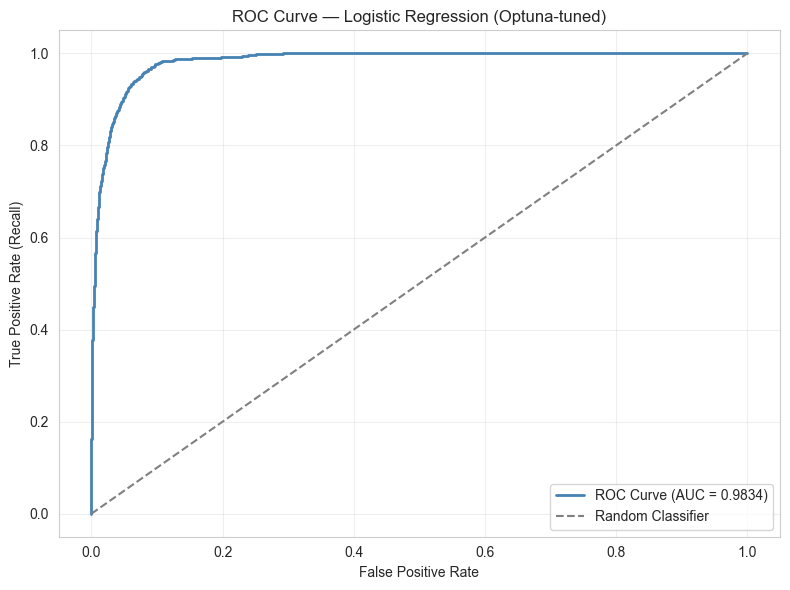

In [65]:
# Compute predicted probabilities (use class 1 — default — probability column)
probabilities = best_model.predict_proba(X_test_encoded)
fpr, tpr, thresholds = roc_curve(y_test, probabilities[:, 1])
area = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {area:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Logistic Regression (Optuna-tuned)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
# Compute summary discrimination metrics
gini_coefficient = 2 * area - 1
print(f"AUC              : {area:.4f}")
print(f"Gini Coefficient : {gini_coefficient:.4f}")

AUC              : 0.9834
Gini Coefficient : 0.9668


---
## 16. Model Evaluation — Rank Order Table & KS Statistic

**Rank Order / Decile Analysis** is a standard credit model validation technique that 
assesses whether the model correctly **ranks** customers by default risk, not just 
classifies them.

**Method:**
1. Rank test-set customers by predicted default probability (descending).
2. Divide into 10 equal-sized deciles (decile 9 = highest predicted risk).
3. Compute actual default rate within each decile.
4. A well-calibrated model shows a **monotonically decreasing** default rate from 
   the highest-risk to the lowest-risk decile — confirming the model's ranking is meaningful.

**KS (Kolmogorov-Smirnov) Statistic:**  
The maximum absolute difference between the cumulative distribution of events (defaults) 
and non-events across deciles. Higher KS = better separation. Credit industry benchmarks:
- KS > 40: good model
- KS > 50: strong model
- KS > 60: excellent model


In [67]:
# Extract default probabilities for the test set
probabilites = best_model.predict_proba(X_test_encoded)[:, 1]

# Build evaluation DataFrame pairing probabilities with ground truth
df_eval = pd.DataFrame({
    'Default Probability': probabilites,
    'Default Truth':       y_test
})
df_eval.head(10)

,Default Probability,Default Truth
19401,2.074216e-07,False
43576,7.014899e-05,False
43161,7.567517e-07,False
8584,5.332841e-03,False
19210,5.950717e-03,False
13306,4.385500e-04,False
3946,1.483066e-02,False
9784,1.444896e-07,False
8296,6.769959e-06,False
7546,4.303398e-01,False


In [68]:
# Assign each record to a decile based on its predicted default probability
# duplicates='drop' handles edge cases where probability values are tied at bin edges
df_eval['decile'] = pd.qcut(
    df_eval['Default Probability'],
    10,
    labels=False,
    duplicates='drop'
)

In [69]:
# Aggregate events and non-events per decile
df_grouped = df_eval.groupby('decile').apply(lambda x: pd.Series({
    'Minimum Probability': x['Default Probability'].min(),
    'Maximum Probability': x['Default Probability'].max(),
    'Events':     x['Default Truth'].sum(),
    'Non-events': x['Default Truth'].count() - x['Default Truth'].sum(),
}))
df_grouped.reset_index(inplace=True)

C:\Users\soham\AppData\Local\Temp\ipykernel_15116\508613470.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_grouped = df_eval.groupby('decile').apply(lambda x: pd.Series({


In [70]:
# Sort descending by decile (highest predicted risk first)
df_grouped.sort_values('decile', ascending=False, inplace=True)
df_grouped

,decile,Minimum Probability,Maximum Probability,Events,Non-events
9,9,8.205266e-01,1.000000e+00,1082.0,418.0
8,8,1.989324e-01,8.203523e-01,188.0,1311.0
7,7,2.443219e-02,1.987919e-01,13.0,1487.0
6,6,3.450362e-03,2.441650e-02,6.0,1493.0
5,5,5.720220e-04,3.441842e-03,0.0,1500.0
4,4,1.100825e-04,5.703265e-04,0.0,1499.0
3,3,2.032553e-05,1.098642e-04,0.0,1500.0
2,2,3.873302e-06,2.032139e-05,0.0,1499.0
1,1,4.694662e-07,3.872521e-06,0.0,1500.0
0,0,7.178957e-10,4.691584e-07,0.0,1500.0


In [71]:
# Compute event and non-event rates within each decile
df_grouped['Event Rate']     = df_grouped['Events']     * 100 / (df_grouped['Events'] + df_grouped['Non-events'])
df_grouped['Non-event Rate'] = df_grouped['Non-events'] * 100 / (df_grouped['Events'] + df_grouped['Non-events'])
df_grouped

,decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
9,9,8.205266e-01,1.000000e+00,1082.0,418.0,72.133333,27.866667
8,8,1.989324e-01,8.203523e-01,188.0,1311.0,12.541694,87.458306
7,7,2.443219e-02,1.987919e-01,13.0,1487.0,0.866667,99.133333
6,6,3.450362e-03,2.441650e-02,6.0,1493.0,0.400267,99.599733
5,5,5.720220e-04,3.441842e-03,0.0,1500.0,0.000000,100.000000
4,4,1.100825e-04,5.703265e-04,0.0,1499.0,0.000000,100.000000
3,3,2.032553e-05,1.098642e-04,0.0,1500.0,0.000000,100.000000
2,2,3.873302e-06,2.032139e-05,0.0,1499.0,0.000000,100.000000
1,1,4.694662e-07,3.872521e-06,0.0,1500.0,0.000000,100.000000
0,0,7.178957e-10,4.691584e-07,0.0,1500.0,0.000000,100.000000


In [72]:
# Compute cumulative events and non-events across deciles
df_grouped['Cum Events']     = df_grouped['Events'].cumsum()
df_grouped['Cum Non-events'] = df_grouped['Non-events'].cumsum()
df_grouped

,decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events
9,9,8.205266e-01,1.000000e+00,1082.0,418.0,72.133333,27.866667,1082.0,418.0
8,8,1.989324e-01,8.203523e-01,188.0,1311.0,12.541694,87.458306,1270.0,1729.0
7,7,2.443219e-02,1.987919e-01,13.0,1487.0,0.866667,99.133333,1283.0,3216.0
6,6,3.450362e-03,2.441650e-02,6.0,1493.0,0.400267,99.599733,1289.0,4709.0
5,5,5.720220e-04,3.441842e-03,0.0,1500.0,0.000000,100.000000,1289.0,6209.0
4,4,1.100825e-04,5.703265e-04,0.0,1499.0,0.000000,100.000000,1289.0,7708.0
3,3,2.032553e-05,1.098642e-04,0.0,1500.0,0.000000,100.000000,1289.0,9208.0
2,2,3.873302e-06,2.032139e-05,0.0,1499.0,0.000000,100.000000,1289.0,10707.0
1,1,4.694662e-07,3.872521e-06,0.0,1500.0,0.000000,100.000000,1289.0,12207.0
0,0,7.178957e-10,4.691584e-07,0.0,1500.0,0.000000,100.000000,1289.0,13707.0


In [73]:
# Compute cumulative event and non-event rates as a percentage of their respective totals
df_grouped['Cum Event Rate']     = df_grouped['Cum Events']     * 100 / df_grouped['Events'].sum()
df_grouped['Cum Non-event Rate'] = df_grouped['Cum Non-events'] * 100 / df_grouped['Non-events'].sum()
df_grouped

,decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate
9,9,8.205266e-01,1.000000e+00,1082.0,418.0,72.133333,27.866667,1082.0,418.0,83.941040,3.049537
8,8,1.989324e-01,8.203523e-01,188.0,1311.0,12.541694,87.458306,1270.0,1729.0,98.525989,12.613993
7,7,2.443219e-02,1.987919e-01,13.0,1487.0,0.866667,99.133333,1283.0,3216.0,99.534523,23.462464
6,6,3.450362e-03,2.441650e-02,6.0,1493.0,0.400267,99.599733,1289.0,4709.0,100.000000,34.354709
5,5,5.720220e-04,3.441842e-03,0.0,1500.0,0.000000,100.000000,1289.0,6209.0,100.000000,45.298023
4,4,1.100825e-04,5.703265e-04,0.0,1499.0,0.000000,100.000000,1289.0,7708.0,100.000000,56.234041
3,3,2.032553e-05,1.098642e-04,0.0,1500.0,0.000000,100.000000,1289.0,9208.0,100.000000,67.177355
2,2,3.873302e-06,2.032139e-05,0.0,1499.0,0.000000,100.000000,1289.0,10707.0,100.000000,78.113373
1,1,4.694662e-07,3.872521e-06,0.0,1500.0,0.000000,100.000000,1289.0,12207.0,100.000000,89.056686
0,0,7.178957e-10,4.691584e-07,0.0,1500.0,0.000000,100.000000,1289.0,13707.0,100.000000,100.000000


In [74]:
# KS statistic per decile — take the maximum as the model's KS score
df_grouped['KS'] = abs(df_grouped['Cum Event Rate'] - df_grouped['Cum Non-event Rate'])

print(f"Maximum KS Statistic: {df_grouped['KS'].max():.2f}")
print("\nFull Rank Order Table:")
df_grouped

Maximum KS Statistic: 85.91

Full Rank Order Table:


,decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate,KS
9,9,8.205266e-01,1.000000e+00,1082.0,418.0,72.133333,27.866667,1082.0,418.0,83.941040,3.049537,80.891503
8,8,1.989324e-01,8.203523e-01,188.0,1311.0,12.541694,87.458306,1270.0,1729.0,98.525989,12.613993,85.911996
7,7,2.443219e-02,1.987919e-01,13.0,1487.0,0.866667,99.133333,1283.0,3216.0,99.534523,23.462464,76.072058
6,6,3.450362e-03,2.441650e-02,6.0,1493.0,0.400267,99.599733,1289.0,4709.0,100.000000,34.354709,65.645291
5,5,5.720220e-04,3.441842e-03,0.0,1500.0,0.000000,100.000000,1289.0,6209.0,100.000000,45.298023,54.701977
4,4,1.100825e-04,5.703265e-04,0.0,1499.0,0.000000,100.000000,1289.0,7708.0,100.000000,56.234041,43.765959
3,3,2.032553e-05,1.098642e-04,0.0,1500.0,0.000000,100.000000,1289.0,9208.0,100.000000,67.177355,32.822645
2,2,3.873302e-06,2.032139e-05,0.0,1499.0,0.000000,100.000000,1289.0,10707.0,100.000000,78.113373,21.886627
1,1,4.694662e-07,3.872521e-06,0.0,1500.0,0.000000,100.000000,1289.0,12207.0,100.000000,89.056686,10.943314
0,0,7.178957e-10,4.691584e-07,0.0,1500.0,0.000000,100.000000,1289.0,13707.0,100.000000,100.000000,0.000000


---
## 17. Model Explainability — SHAP

**Why explainability matters in credit risk:**  
Regulatory frameworks (e.g. GDPR Article 22, Equal Credit Opportunity Act) require that 
automated credit decisions be explainable. A model that cannot be interpreted is not 
deployable in most financial institutions regardless of its predictive accuracy.

**SHAP (SHapley Additive exPlanations):**  
SHAP values are grounded in cooperative game theory. Each feature's SHAP value 
represents its **marginal contribution** to a specific prediction, averaged over all 
possible orderings of features. They satisfy three desirable properties:
- **Local accuracy:** SHAP values sum to the difference between the prediction and the base rate.
- **Missingness:** Features not present contribute 0.
- **Consistency:** If a model relies more on a feature, its SHAP value increases.

**Summary plot interpretation:**  
- Each dot represents one test-set record.
- X-axis: SHAP value (positive = pushes prediction toward default; negative = away from default).
- Colour: Feature value (red = high, blue = low).
- Features are sorted by mean absolute SHAP value (top = most important globally).

> **Boolean column cast:** `shap.Explainer` requires numeric input. 
> Boolean columns created by `pd.get_dummies` are explicitly cast to `int` before 
> passing to SHAP to avoid type errors.


In [75]:
# Cast boolean dummy columns to int (required by shap.Explainer)
X_train_shap = X_train_smote.copy()
X_test_shap  = X_test_encoded.copy()

bool_cols = X_train_shap.select_dtypes(include='bool').columns
X_train_shap[bool_cols] = X_train_shap[bool_cols].astype(int)
X_test_shap[bool_cols]  = X_test_shap[bool_cols].astype(int)

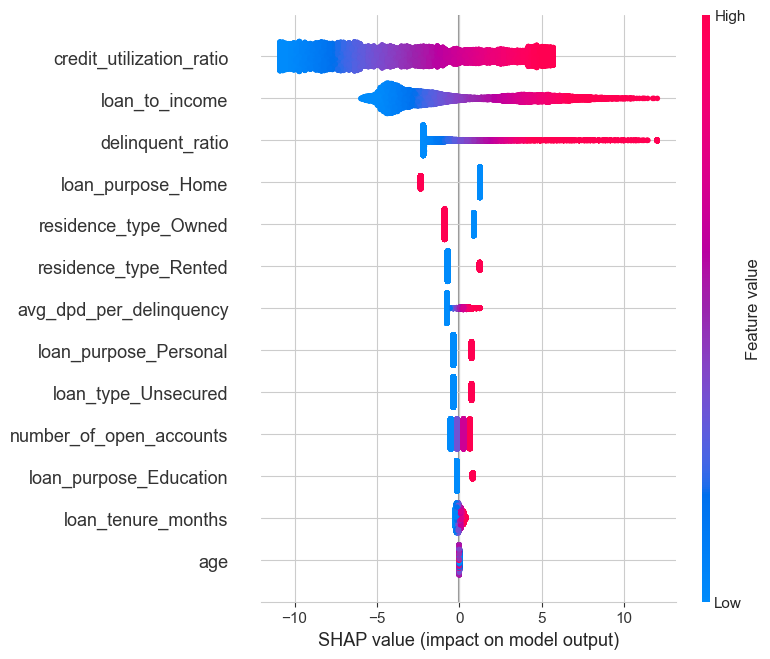

In [76]:
# Build SHAP explainer using the training set as background data
# The background data defines the 'expected value' baseline for SHAP calculations
explainer   = shap.Explainer(best_model, X_train_shap)
shap_values = explainer(X_test_shap)

# Summary plot: global feature importance ranked by mean |SHAP|
shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=X_train_shap.columns,
    show=True
)

---
## 18. Model Export for Production

The final model artefact is serialised using `joblib` (preferred over `pickle` for 
scikit-learn objects due to efficient handling of large numpy arrays).

The exported bundle includes **all components needed to reproduce a prediction at 
inference time**, without requiring the training data:

| Key | Type | Purpose at Inference |
|-----|------|----------------------|
| `model` | `LogisticRegression` | Generates probability scores from processed features |
| `features` | `pd.Index` | Ordered list of expected input columns — enforces schema at API boundary |
| `scaler` | `MinMaxScaler` | Scales numeric features identically to training (fitted on train only) |
| `cols_to_scale` | `pd.Index` | Identifies which columns the scaler should be applied to |

> **Production inference workflow:**  
> 1. Load `credit_risk.joblib`  
> 2. Apply feature engineering (ratio features) to incoming data  
> 3. Apply `scaler.transform(X[cols_to_scale])`  
> 4. One-hot encode and reindex to `features` (fill missing with 0)  
> 5. Call `model.predict_proba(X)[:, 1]` to get default probability score


In [77]:
import os
os.makedirs('./artifacts', exist_ok=True)

# Bundle all inference-time components into a single serialisable dictionary
model_data = {
    'model':        best_model,
    'features':     X_train_encoded.columns,  # Expected column schema
    'scaler':       scaler,                   # Fitted MinMaxScaler
    'cols_to_scale':cols_to_scale             # Columns the scaler applies to
}

# Serialise to disk
dump(model_data, './artifacts/credit_risk.joblib')
print("Model artefact saved to: ./artifacts/credit_risk.joblib")
print("Bundle contains:", list(model_data.keys()))

Model artefact saved to: ./artifacts/credit_risk.joblib
Bundle contains: ['model', 'features', 'scaler', 'cols_to_scale']


---

## ✅ Pipeline Complete

| Stage | Decision |
|-------|----------|
| Data | 3-table relational merge on `cust_id` |
| Leakage prevention | Train-test split performed before any EDA or imputation |
| Imputation | Mode imputation for `residence_type` (derived from train only) |
| Outlier removal | Domain-rule filtering: processing fee > 3%, typo correction |
| Feature engineering | 3 ratio features: loan-to-income, delinquent ratio, avg DPD per delinquency |
| Multicollinearity | VIF-based removal of 5 financially correlated features |
| Feature selection | Information Value threshold IV > 0.02 |
| Encoding | One-hot encoding with `drop_first=True` |
| Class imbalance | SMOTETomek hybrid resampling (train only) |
| Hyperparameter tuning | Bayesian optimisation via Optuna (50 trials per model) |
| Final model | Logistic Regression — Optuna-tuned — CV macro F1: **0.9776** |
| Evaluation | Classification report, ROC-AUC, Gini coefficient, KS statistic, decile analysis |
| Explainability | SHAP summary plot for global feature importance |
| Deployment | `./artifacts/credit_risk.joblib` — model + scaler + feature schema |
